<a href="https://colab.research.google.com/github/kotatech24/AIML/blob/main/day7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Whenever a dependent variable is categorical in nature, we use the activation function as sigmoid.
# When we have multiple categories in the output, we use the loss function as sparse categorical cross entropy
# When we have two categories in the output, we use the loss function as binary cross entropy.
# When we have a dependent variable as continuous in nature, like minus infinity to plus infinity,
# we use stochastic gradient descent.

# activation functions

#sigmoid

import math
def sigmoid(x):
  return 1/(1 + math.exp(-x))

#sigmoid o/p ranges from 0 to 1 as probability values

In [2]:
sigmoid(100)

1.0

In [3]:
sigmoid(-56)

4.780892883885469e-25

In [4]:
sigmoid(0.5)

0.6224593312018546

In [5]:
# tanh
def tanh(x):
  return (math.exp(x) - math.exp(-x)) / (math.exp(x) + math.exp(-x))

In [6]:
tanh(-56)

-1.0

In [7]:
tanh(50)

1.0

In [8]:
tanh(1)

0.7615941559557649

In [9]:
# RELU - when value negative ans is 0 and when value is positive ans is positive

def relu(x):
  return max(0,x)

relu(-100)

0

In [10]:
relu(8)

8

In [11]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns # i am importing so that I can create heat map - correlation between variables
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [18]:
white = pd.read_csv('winequality-white.csv', sep = ';')
red = pd.read_csv('winequality-red.csv', sep = ';')

In [19]:
white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [20]:
red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [15]:
import google.colab.files as files
uploaded = files.upload()

Saving winequality-white.csv to winequality-white.csv


In [16]:
import google.colab.files as files
uploaded = files.upload()

Saving winequality-red.csv to winequality-red.csv


In [21]:
white["type"] = 0 # i am adding new column called type in white dataframe where all values are 0
red["type"] = 1 # i am adding new column called type in red dataframe where all values are 1
print("White shape is ", white.shape)
print("red shape is ", red.shape)

White shape is  (4898, 13)
red shape is  (1599, 13)


In [22]:
4898+1599

6497

In [23]:
wine = pd.concat([white, red], axis = 0) #axis = 0 means one below another
wine.shape

(6497, 13)

In [24]:
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,0
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,0
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,0
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,0
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,0


In [25]:
wine = wine.sample(frac = 1)
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
3364,6.0,0.20,0.26,1.10,0.033,38.0,67.0,0.98954,3.14,0.38,11.5,6,0
2821,6.6,0.40,0.46,6.20,0.056,42.0,241.0,0.99680,3.50,0.60,9.9,5,0
1588,7.2,0.66,0.33,2.50,0.068,34.0,102.0,0.99414,3.27,0.78,12.8,6,1
1473,7.0,0.20,0.49,5.90,0.038,39.0,128.0,0.99380,3.21,0.48,10.8,6,0
261,6.9,0.29,0.40,19.45,0.043,36.0,156.0,0.99960,2.93,0.47,8.9,5,0


In [26]:
wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,0.246114
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,0.430779
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,0.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,0.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,0.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000


In [27]:
corr = wine.corr()
corr

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
fixed acidity,1.000000,0.219008,0.324436,-0.111981,0.298195,-0.282735,-0.329054,0.458910,-0.252700,0.299568,-0.095452,-0.076743,0.486740
volatile acidity,0.219008,1.000000,-0.377981,-0.196011,0.377124,-0.352557,-0.414476,0.271296,0.261454,0.225984,-0.037640,-0.265699,0.653036
citric acid,0.324436,-0.377981,1.000000,0.142451,0.038998,0.133126,0.195242,0.096154,-0.329808,0.056197,-0.010493,0.085532,-0.187397
residual sugar,-0.111981,-0.196011,0.142451,1.000000,-0.128940,0.402871,0.495482,0.552517,-0.267320,-0.185927,-0.359415,-0.036980,-0.348821
chlorides,0.298195,0.377124,0.038998,-0.128940,1.000000,-0.195045,-0.279630,0.362615,0.044708,0.395593,-0.256916,-0.200666,0.512678
free sulfur dioxide,-0.282735,-0.352557,0.133126,0.402871,-0.195045,1.000000,0.720934,0.025717,-0.145854,-0.188457,-0.179838,0.055463,-0.471644
total sulfur dioxide,-0.329054,-0.414476,0.195242,0.495482,-0.279630,0.720934,1.000000,0.032395,-0.238413,-0.275727,-0.265740,-0.041385,-0.700357
density,0.458910,0.271296,0.096154,0.552517,0.362615,0.025717,0.032395,1.000000,0.011686,0.259478,-0.686745,-0.305858,0.390645
pH,-0.252700,0.261454,-0.329808,-0.267320,0.044708,-0.145854,-0.238413,0.011686,1.000000,0.192123,0.121248,0.019506,0.329129
sulphates,0.299568,0.225984,0.056197,-0.185927,0.395593,-0.188457,-0.275727,0.259478,0.192123,1.000000,-0.003029,0.038485,0.487218


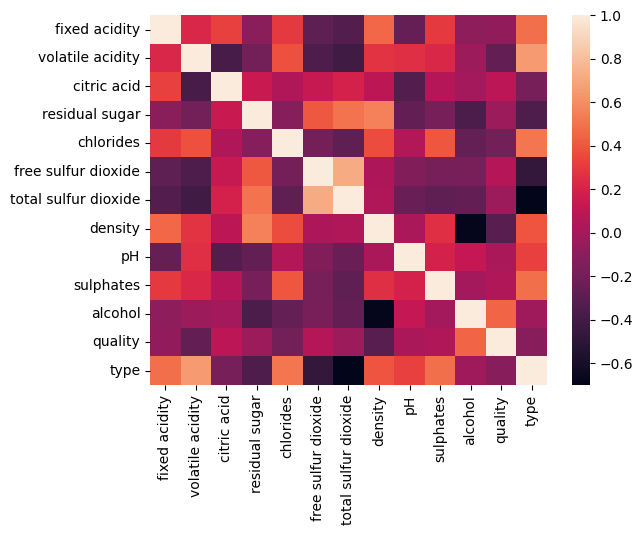

In [28]:
sns.heatmap(corr)
plt.show()

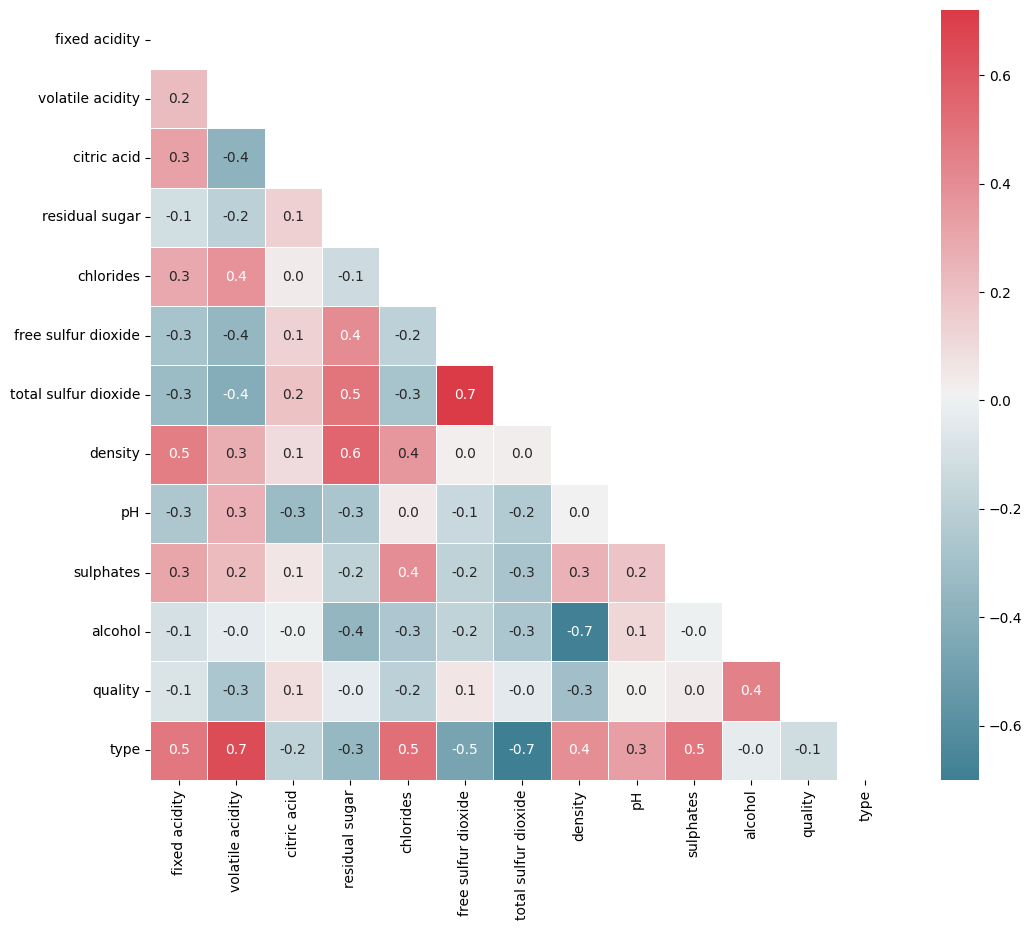

In [29]:
# when correlation between variables are high, we keep one of them and drop rest of them so that we do not feed
# duplicate information to the algorithm
corr = wine.corr()
f,ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype = bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr, annot=True, mask = mask, cmap = cmap, linewidths=.5, fmt= '.1f',ax=ax)
plt.show()

In [30]:
wine.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [31]:
# machine learning - we define independent variable and dependent variable
x = wine.drop("type", axis = 1)
y = wine["type"]


In [32]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 2)
model = LogisticRegression()
model.fit(x_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [33]:
y_pred = model.predict(x_test)
print("accuracy of ML model is ", accuracy_score(y_test, y_pred)*100, "Percent accuracy")

accuracy of ML model is  97.94871794871794 Percent accuracy


In [34]:
new_data = pd.read_csv('/content/input_data.csv', sep = ';', header = None)
new_data

FileNotFoundError: [Errno 2] No such file or directory: '/content/input_data.csv'

In [35]:
list1 = list(red.columns)
list1.remove('type')
new_data.columns = list1
new_data

NameError: name 'new_data' is not defined

In [36]:
pred_value = model.predict(new_data)
pred_value

NameError: name 'new_data' is not defined

In [38]:
# deep learning part
from keras.models import Sequential
from keras.layers import Dense

In [39]:
x = wine.iloc[:,0:11]
x.shape

(6497, 11)

In [40]:
y = np.ravel(wine.type) # convert dependent variable to single dimention numpy array
y

array([0, 0, 1, ..., 0, 0, 1])

In [41]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 2)

In [42]:
model_deep = Sequential()
model_deep.add(Dense(120, activation='relu', input_shape=(11,)))
model_deep.add(Dense(90, activation='relu'))
model_deep.add(Dense(80, activation='tanh'))
model_deep.add(Dense(40, activation='tanh'))
model_deep.add(Dense(10, activation='relu'))
model_deep.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
model_deep.compile(loss = 'binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model_deep.fit(x_train, y_train, epochs=5, batch_size=1, verbose=1)

Epoch 1/5
4547/4547 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9180 - loss: 0.2573
Epoch 2/5
3959/4547 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9286 - loss: 0.2376

KeyboardInterrupt: 

In [ ]:
y_pred = model_deep.predict(x_test)

In [44]:
loss, accuracy = model_deep.evaluate(x_test, y_test, verbose=1)
print("accuracy of deep learning model is  ", accuracy*100, "percent")

61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9374 - loss: 0.2027
accuracy of deep learning model is   93.74359250068665 percent


In [45]:
y_pred

array([1, 1, 0, ..., 0, 0, 0])

In [46]:
np.argmax(y_pred[0])

np.int64(0)